In [1]:
!pip install -q "gymnasium[box2d]" stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.9 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
env = gym.make("LunarLander-v3")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [4]:
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
model.learn(total_timesteps=20000)

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 68.8     |
|    ep_rew_mean      | -117     |
|    exploration_rate | 0.869    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4486     |
|    time_elapsed     | 0        |
|    total_timesteps  | 275      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 79.1     |
|    ep_rew_mean      | -128     |
|    exploration_rate | 0.699    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4859     |
|    time_elapsed     | 0        |
|    total_timesteps  | 633      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 82.2     |
|    ep_rew_mean      | -138     |
|    exploration_rate | 0.531    |
| time/               |          |
|    episodes       

In [6]:
model.save("lunar_lander_dqn")

print("Training completed!")

Training completed!


In [7]:
test_env = gym.make("LunarLander-v3")

state, info = test_env.reset()

total_reward = 0
done = False

while not done:

    action, _ = model.predict(state, deterministic=True)

    state, reward, terminated, truncated, info = test_env.step(action)

    total_reward += reward

    done = terminated or truncated

print("Total Reward:", total_reward)

test_env.close()

Total Reward: 82.96291936119466


In [8]:
rewards = []

for episode in range(10):

    state, info = test_env.reset()
    total_reward = 0
    done = False

    while not done:

        action, _ = model.predict(state, deterministic=True)

        state, reward, terminated, truncated, info = test_env.step(action)

        total_reward += reward
        done = terminated or truncated

    rewards.append(total_reward)

    print(
        "Episode", episode + 1,
        "Reward:", round(total_reward, 2)
    )

Episode 1 Reward: -90.84
Episode 2 Reward: 198.69
Episode 3 Reward: -45.7
Episode 4 Reward: -76.69
Episode 5 Reward: 213.54
Episode 6 Reward: -67.04
Episode 7 Reward: 48.52
Episode 8 Reward: -205.72
Episode 9 Reward: -242.76
Episode 10 Reward: -172.49


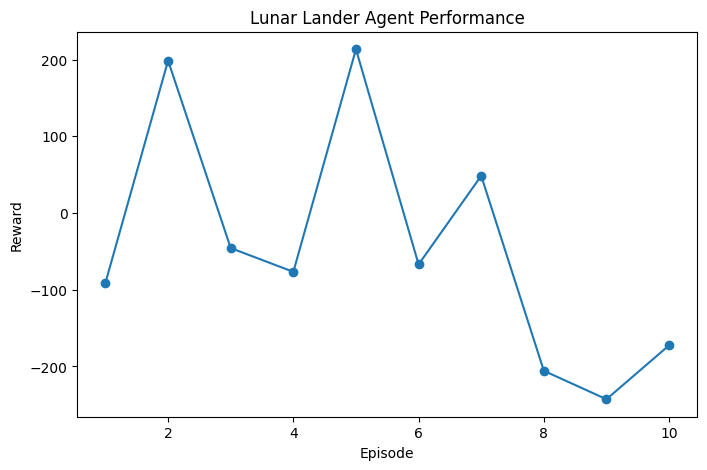

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    rewards,
    marker="o"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Lunar Lander Agent Performance")

plt.show()

In [10]:
print("Average Reward:", np.mean(rewards))

Average Reward: -44.04882488574958


In [11]:
# CELL 1
!pip install -q "gymnasium[box2d]" stable-baselines3

In [12]:
# CELL 2
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN

In [13]:
# CELL 3
env = gym.make("LunarLander-v3")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


In [14]:
# CELL 4
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [15]:
# CELL 5
model.learn(total_timesteps=20000)

model.save("lunar_lander_dqn")

print("Training completed!")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93       |
|    ep_rew_mean      | -174     |
|    exploration_rate | 0.823    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5388     |
|    time_elapsed     | 0        |
|    total_timesteps  | 372      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.5     |
|    ep_rew_mean      | -145     |
|    exploration_rate | 0.652    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5581     |
|    time_elapsed     | 0        |
|    total_timesteps  | 732      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.4     |
|    ep_rew_mean      | -187     |
|    exploration_rate | 0.45     |
| time/               |          |
|    episodes       

In [16]:
# CELL 6
test_env = gym.make("LunarLander-v3")

rewards = []

for episode in range(10):

    state, info = test_env.reset()
    total_reward = 0
    done = False

    while not done:

        action, _ = model.predict(
            state,
            deterministic=True
        )

        state, reward, terminated, truncated, info = test_env.step(action)

        total_reward += reward
        done = terminated or truncated

    rewards.append(total_reward)

    print(
        "Episode", episode + 1,
        "Reward:", round(total_reward, 2)
    )

test_env.close()

Episode 1 Reward: -221.48
Episode 2 Reward: 109.87
Episode 3 Reward: 82.88
Episode 4 Reward: 21.94
Episode 5 Reward: -250.04
Episode 6 Reward: 118.37
Episode 7 Reward: -168.12
Episode 8 Reward: -3.53
Episode 9 Reward: 258.81
Episode 10 Reward: -139.45


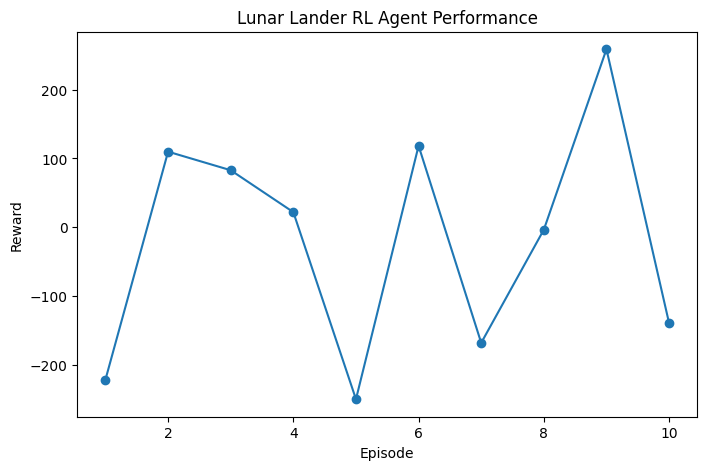

Average Reward: -19.074873548242937


In [17]:
# CELL 7
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    rewards,
    marker="o"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Lunar Lander RL Agent Performance")

plt.show()

print("Average Reward:", np.mean(rewards))